## Example with significance

The `Stats` enhances PySubgroup by adding **statistical significance** testing (via permutation tests) to subgroup discovery. 

1. Wrap your search strategy (e.g., `BeamSearch()`) with `Stats`
2. Results include **p-values** and **adjusted p-values** (via `result.to_dataframe()`). **Z-scores** only if *normality* is passed.

In [1]:
import pysubgroup as ps
from pysubgroup.datasets import get_titanic_data

data = get_titanic_data() 

task = ps.SubgroupDiscoveryTask(
    data,
    ps.BinaryTarget("Survived", True),
    ps.create_selectors(data, ignore=["Survived", "Name", "Ticket"]),
    result_set_size=5,
    depth=2,
    qf=ps.StandardQF(0.5)
)

wrapper = ps.Stats(ps.BeamSearch(), num_permutations=1000)
result = wrapper.execute(task)
result.to_dataframe()


Generating null distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift,p_value,p_value_adj
0,0.220564,Sex=='female',56,156,40,54,100,0.358974,0.641026,0.740741,0.259259,0.714286,0.140000,0.346154,2.063492,0.000999,0.004995
1,0.197697,Sex=='female' AND SibSp: [0:1[,25,156,21,54,131,0.160256,0.839744,0.388889,0.611111,0.840000,0.251908,0.346154,2.426667,0.000999,0.004995
2,0.197658,Parch==0 AND Sex=='female',41,156,30,54,115,0.262821,0.737179,0.555556,0.444444,0.731707,0.208696,0.346154,2.113821,0.000999,0.004995
3,0.158232,Pclass==2 AND Sex=='female',12,156,11,54,144,0.076923,0.923077,0.203704,0.796296,0.916667,0.298611,0.346154,2.648148,0.002997,0.005994
4,0.157049,Pclass==1 AND Sex=='female',9,156,9,54,147,0.057692,0.942308,0.166667,0.833333,1.000000,0.306122,0.346154,2.888889,0.003996,0.005994


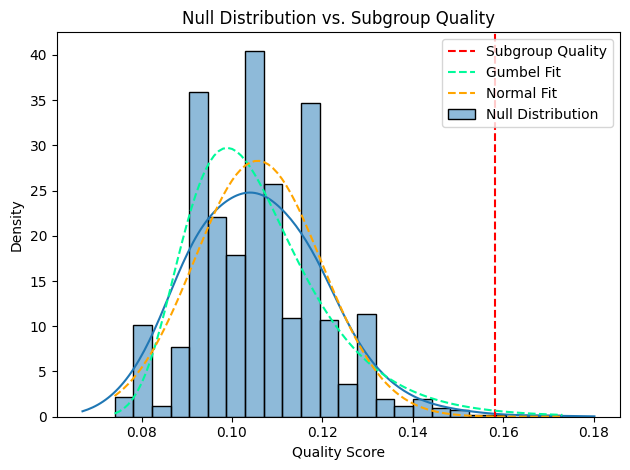

In [5]:
ps.plot_null_distribution(
    wrapper.null_distribution, # Null distribution
    result.results[3][0],   # Quality of the subgroup at idx 3
    bw_adjust=2,            # Increase smoothness of the KDE (optional, default=1)
    compare_gumbel=True,   # Compare with Gumbel distribution
    compare_normal=True,    # Compare with Normal distribution (CLT)
)

In [3]:
import pysubgroup as ps
from pysubgroup.datasets import get_credit_data

data2 = get_credit_data()
data2 = data2.map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

task2 = ps.SubgroupDiscoveryTask(
    data2, 
    ps.BinaryTarget('class', 'good'), 
    ps.create_selectors(data2, ignore=['class']), 
    result_set_size=10, 
    depth=2, 
    qf=ps.WRAccQF()
)

wrapper2 = ps.Stats(ps.BeamSearch(), num_permutations=1000)
result2 = wrapper2.execute(task2)
result2.to_dataframe()

Generating null distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift,standardized_value,p_value,p_value_adj
0,0.0722,checking_status=='no checking',394,1000,348,700,606,0.394,0.606,0.497143,0.502857,0.883249,0.580858,0.7,1.261784,23.068298,9.584413e-11,9.584413e-10
1,0.0720,checking_status=='no checking' AND other_payme...,330,1000,303,700,670,0.330,0.670,0.432857,0.567143,0.918182,0.592537,0.7,1.311688,22.987440,1.039158e-10,9.584413e-10
2,0.0699,checking_status=='no checking' AND other_parti...,373,1000,331,700,627,0.373,0.627,0.472857,0.527143,0.887399,0.588517,0.7,1.267714,22.138430,2.428856e-10,1.943085e-09
3,0.0683,checking_status=='no checking' AND foreign_wor...,381,1000,335,700,619,0.381,0.619,0.478571,0.521429,0.879265,0.589661,0.7,1.256093,21.491566,4.638007e-10,3.246605e-09
4,0.0613,checking_status=='no checking' AND num_depende...,331,1000,293,700,669,0.331,0.669,0.418571,0.581429,0.885196,0.608371,0.7,1.264566,18.661535,7.859563e-09,4.715738e-08
5,0.0592,checking_status=='no checking' AND housing=='own',304,1000,272,700,696,0.304,0.696,0.388571,0.611429,0.894737,0.614943,0.7,1.278195,17.812525,1.837040e-08,9.185198e-08
6,0.0528,checking_status=='no checking' AND job=='skilled',266,1000,239,700,734,0.266,0.734,0.341429,0.658571,0.898496,0.628065,0.7,1.283566,15.225068,2.442513e-07,9.770052e-07
7,0.0456,checking_status=='no checking' AND personal_st...,232,1000,208,700,768,0.232,0.768,0.297143,0.702857,0.896552,0.640625,0.7,1.280788,12.314179,4.487652e-06,1.346295e-05
8,0.0436,checking_status=='no checking' AND existing_cr...,222,1000,199,700,778,0.222,0.778,0.284286,0.715714,0.896396,0.643959,0.7,1.280566,11.505598,1.007349e-05,2.014698e-05
9,0.0423,credit_history=='critical/other existing credi...,251,1000,218,700,749,0.251,0.749,0.311429,0.688571,0.868526,0.643525,0.7,1.240751,10.980021,1.703859e-05,2.014698e-05


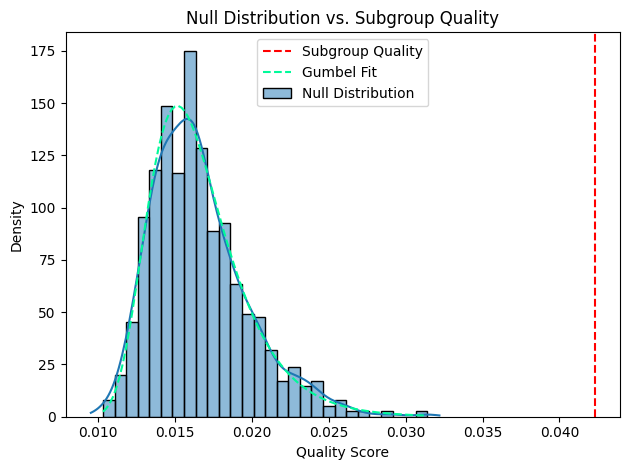

In [4]:
ps.plot_null_distribution(
    wrapper2.null_distribution, # Null distribution
    result2.results[9][0],  # Quality of the subgroup at idx 3
    bw_adjust=1,            # Increase smoothness of the KDE (optional, default=1)
    compare_gumbel=True,    # Compare with Gumbel distribution
    compare_normal=False,   # Compare with Normal distribution (CLT)
)